# Protein Analysis Workflow

Two common starting points for protein TMAP:

- **Part A** — You have a FASTA file and want to explore sequence properties
- **Part B** — You have pre-computed embeddings (ESM-2, ProtTrans, etc.) and want
  to build a large-scale map with AlphaFold / UniProt annotations

This notebook shows both, then demonstrates `add_metadata` and `fetch_alphafold`
to annotate the map.

**Requirements:** `pip install tmap2`

---
## Part A: From FASTA to TMAP

The most common starting point — you have a FASTA file of protein sequences.

TMAP provides three file readers in `tmap.utils`:

| Format | Function | Input |
|--------|----------|-------|
| FASTA (.fa, .fasta) | `read_fasta(path)` | Sequences + headers |
| CSV / TSV | `read_protein_csv(path, id_col, seq_col)` | Tabular data |
| ID list (.txt) | `read_id_list(path)` | One UniProt accession per line |


### 1. Load sequences from FASTA


In [1]:
import numpy as np
from tmap.utils import read_fasta

# SCOPe ASTRAL 40% subset — protein domains with structural classification
ids_fasta, sequences = read_fasta("../examples/data/scope_cache/astral_40.fa", max_seqs=50_000)

print(f"{len(sequences)} sequences loaded")
print(f"Length range: {min(len(s) for s in sequences)} – {max(len(s) for s in sequences)} aa")
print(f"First ID:  {ids_fasta[0]}")
print(f"First seq: {sequences[0][:60]}...")


15177 sequences loaded
Length range: 20 – 1664 aa
First ID:  d1dlwa_
First seq: SLFEQLGGQAAVQAVTAQFYANIQADATVATFFNGIDMPNQTNKTAAFLCAALGGPNAWT...


The other readers work the same way:

```python
# CSV/TSV with header row
ids, seqs = read_protein_csv("proteins.csv", id_col="accession", seq_col="sequence")

# Plain text ID list (one per line, # comments allowed)
ids = read_id_list("uniprot_ids.txt")
```


### 2. Compute sequence properties

`sequence_properties` computes physicochemical descriptors from amino acid
sequences — no external dependencies, no network access.


In [2]:
from tmap.utils import sequence_properties

seq_props = sequence_properties(sequences)

for key, values in seq_props.items():
    print(f"{key:25s}  min={np.nanmin(values):8.1f}  max={np.nanmax(values):10.1f}")


sequence_properties: 366/15177 sequences invalid (non-standard AAs or empty)


length                     min=    20.0  max=    1664.0
molecular_weight           min=  2044.0  max=  186314.3
isoelectric_point          min=     2.6  max=      13.2
gravy                      min=    -2.0  max=       2.5
charge_at_ph7              min=   -52.3  max=      24.3
aromaticity                min=     0.0  max=       0.3
aliphatic_index            min=     0.0  max=     197.8
frac_charged               min=     0.0  max=       0.5
frac_hydrophobic           min=     0.0  max=       0.8
frac_polar                 min=     0.0  max=       0.7
frac_acidic                min=     0.0  max=       0.4
frac_basic                 min=     0.0  max=       0.4
n_cysteines                min=     0.0  max=      32.0


### 3. Build a TMAP from sequences

For a quick exploration without pre-computed embeddings, we can encode
sequences as **k-mer frequency vectors** and use cosine distance.
This is fast and dependency-free — a good first pass before investing in
ESM-2 embeddings.


In [3]:
from collections import Counter

def kmer_features(sequences, k=3):
    """Encode sequences as k-mer frequency vectors."""
    all_kmers = set()
    counters = []
    for seq in sequences:
        seq = seq.upper()
        c = Counter(seq[i:i+k] for i in range(len(seq) - k + 1))
        counters.append(c)
        all_kmers.update(c.keys())

    kmer_list = sorted(all_kmers)
    kmer_idx = {km: i for i, km in enumerate(kmer_list)}
    X = np.zeros((len(sequences), len(kmer_list)), dtype=np.float32)
    for i, c in enumerate(counters):
        total = sum(c.values())
        for km, count in c.items():
            X[i, kmer_idx[km]] = count / total
    return X

X = kmer_features(sequences, k=3)
print(f"Feature matrix: {X.shape}  (3-mer frequencies)")


Feature matrix: (15177, 8653)  (3-mer frequencies)


In [5]:
from tmap import TMAP

model_fasta = TMAP(metric="cosine", n_neighbors=15, seed=42).fit(X)

print(f"Embedding: {model_fasta.embedding_.shape}")
print(f"Tree edges: {model_fasta.tree_.edges.shape[0]}")


  Using cached usearch-2.23.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (33 kB)
  Using cached simsimd-6.5.16-cp312-cp312-macosx_11_0_arm64.whl.metadata (70 kB)
Using cached usearch-2.23.0-cp312-cp312-macosx_11_0_arm64.whl (401 kB)
Using cached simsimd-6.5.16-cp312-cp312-macosx_11_0_arm64.whl (94 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [usearch]
Note: you may need to restart the kernel to use updated packages.
Embedding: (15177, 2)
Tree edges: 15176


### 4. Add metadata and visualize

Pass the sequence properties dict directly to `add_metadata` — it
auto-detects continuous vs. categorical for each column.


In [7]:
import re

viz = model_fasta.to_tmapviz()
viz.title = "SCOPe Protein Domains — 3-mer TMAP"

# Bulk-add all sequence properties as color layers
for key in seq_props.keys():
    viz.add_color_layout(key, seq_props[key])

# Parse SCOP class from headers (a=all-alpha, b=all-beta, c=a/b, d=a+b, ...)
scop_class_names = {
    "a": "All-alpha", "b": "All-beta", "c": "Alpha/beta",
    "d": "Alpha+beta", "e": "Multi-domain", "f": "Membrane", "g": "Small",
}
scop_re = re.compile(r"\s([a-g])\.\d+\.\d+\.\d+\s")
classes = []
for h in ids_fasta:
    m = scop_re.search(h)
    classes.append(scop_class_names.get(m.group(1), "other") if m else "other")

viz.add_color_layout("SCOP class", classes, categorical=True, color="Set2")

print(f"Layouts: {[l.name for l in viz.layouts]}")
viz.show()


Layouts: ['length', 'molecular_weight', 'isoelectric_point', 'gravy', 'charge_at_ph7', 'aromaticity', 'aliphatic_index', 'frac_charged', 'frac_hydrophobic', 'frac_polar', 'frac_acidic', 'frac_basic', 'n_cysteines', 'SCOP class']


/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_81674/2397682253.py:8: UserWarning: Continuous layout 'length' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout(key, seq_props[key])
/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_81674/2397682253.py:8: UserWarning: Continuous layout 'molecular_weight' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout(key, seq_props[key])
/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_81674/2397682253.py:8: UserWarning: Continuous layout 'isoelectric_point' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout(key, seq_props[key])
/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_81674/2397682253.py:8: UserWarning: Continuous layout 'gravy' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout(key, seq_props[key])
/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r

<Axes: >

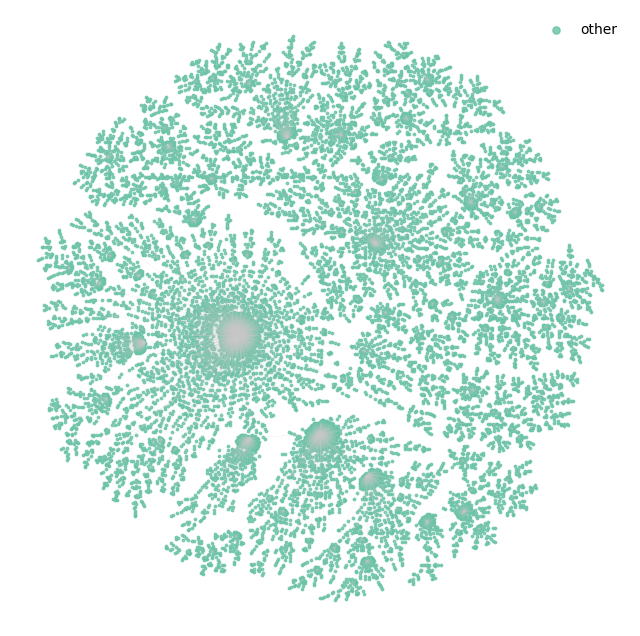

In [8]:
model_fasta.plot_static(color_by=classes, color_map="Set2", point_size=3)


---
## Part B: Pre-computed embeddings + API annotations

For production protein TMAPs, you typically have:

1. **Embeddings** from ESM-2, ProtTrans, or similar (`.npy` files)
2. **UniProt IDs** for each protein

We load 49k ESM-2 embeddings and annotate them with AlphaFold structural
metadata and UniProt annotations.


### 5. Load embeddings


In [9]:
embeddings = np.load("../data/embeddings.npy").astype(np.float32)
ids = np.load("../data/ids.npy", allow_pickle=True)

print(f"Embeddings: {embeddings.shape} ({embeddings.dtype})")
print(f"IDs: {ids.shape}")
print(f"Sample IDs: {ids[:5]}")


FileNotFoundError: [Errno 2] No such file or directory: '../data/embeddings.npy'

### 6. Fit TMAP on embeddings

ESM-2 embeddings are dense float vectors, so use `metric='cosine'`.
USearch handles the dense nearest-neighbor search automatically.


In [10]:
# Euclidean is the recommended for ESM embeddings. Cosine should work as well
model = TMAP(metric="euclidean", n_neighbors=20, seed=42).fit(embeddings)

print(f"Embedding: {model.embedding_.shape}")
print(f"Tree edges: {model.tree_.edges.shape[0]}")


NameError: name 'embeddings' is not defined

### 7. Fetch AlphaFold structural metadata

`fetch_alphafold` queries the AlphaFold DB REST API — one request per protein,
threaded with 20 workers. For 49k proteins this takes a few minutes.

Returns `float32` arrays with NaN for proteins not in AlphaFold DB (~14% missing).


In [9]:
from tmap.utils import fetch_alphafold

af_data = fetch_alphafold(ids.tolist())

for key, values in af_data.items():
    n_ok = np.sum(~np.isnan(values))
    print(f"{key:20s}  {n_ok:,}/{len(values):,} fetched  "
          f"mean={np.nanmean(values):.2f}")


  [AlphaFold] fetched 999/49,223
  [AlphaFold] fetched 1,999/49,223
  [AlphaFold] fetched 2,999/49,223
  [AlphaFold] fetched 3,999/49,223
  [AlphaFold] fetched 4,999/49,223
  [AlphaFold] fetched 5,999/49,223
  [AlphaFold] fetched 6,999/49,223
  [AlphaFold] fetched 7,999/49,223
  [AlphaFold] fetched 8,999/49,223
  [AlphaFold] fetched 9,999/49,223
  [AlphaFold] fetched 10,999/49,223
  [AlphaFold] fetched 11,999/49,223
  [AlphaFold] fetched 12,999/49,223
  [AlphaFold] fetched 13,999/49,223
  [AlphaFold] fetched 14,999/49,223
  [AlphaFold] fetched 15,999/49,223
  [AlphaFold] fetched 16,999/49,223
  [AlphaFold] fetched 17,999/49,223
  [AlphaFold] fetched 18,999/49,223
  [AlphaFold] fetched 19,999/49,223
  [AlphaFold] fetched 20,999/49,223
  [AlphaFold] fetched 21,999/49,223
  [AlphaFold] fetched 22,999/49,223
  [AlphaFold] fetched 23,999/49,223
  [AlphaFold] fetched 24,999/49,223
  [AlphaFold] fetched 25,999/49,223
  [AlphaFold] fetched 26,999/49,223
  [AlphaFold] fetched 26,999/49,223
  [A

### 8. Fetch UniProt annotations

`fetch_uniprot` batch-fetches text annotations (organism, GO terms,
subcellular location, etc.) via the UniProt REST API.


In [10]:
from tmap.utils import fetch_uniprot

up_data = fetch_uniprot(ids.tolist())

# Show a few
for i in range(5):
    name = str(up_data["protein_name"][i])[:40]
    org = str(up_data["organism_name"][i])[:30]
    print(f"  {ids[i]:12s}  {name:40s}  {org}")


  [UniProt] fetched 49,223/49,223 entries (0 chunk failures)
  A0A6A4IZ81    deleted                                   
  A0A1I8HDW0    ANK_REP_REGION domain-containing protein  Macrostomum lignano
  W6Q037        Flavoprotein transmembrane component      Penicillium roqueforti (strain
  A0A4V1C829    Heterokaryon incompatibility domain-cont  Pyricularia oryzae (Rice blast
  A0A158JXS0    Uncharacterized protein                   Caballeronia udeis


### 9. Visualize with `add_metadata`

Now we combine everything into a single visualization. `add_metadata`
auto-detects continuous vs categorical — pass the AlphaFold dict directly.


In [ ]:
viz = model.to_tmapviz()
viz.title = "Protein Embedding Space — 49k ESM-2"

# AlphaFold structural metrics as color layers

# UniProt annotation score as a color layer
viz.add_color_layout("Length", up_data["length"].tolist())
viz.add_color_layout("annotation_score", up_data["annotation_score"].tolist(),
                     categorical=False, color="viridis")
# # UniProt text fields as tooltip labels
viz.add_label("Subcelullar Location", up_data["cc_subcellular_location"].tolist())
viz.add_label("Protein", list(up_data["protein_name"]))
viz.add_label("Organism", list(up_data["organism_name"]))

# Clickable UniProt links + AlphaFold 3D structure viewer
viz.add_protein_ids(ids.tolist())

print(f"Color layers: {[l.name for l in viz.layouts]}")


Color layers: ['Length', 'annotation_score']


/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_80254/965458510.py:7: UserWarning: Continuous layout 'Length' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout("Length", up_data["length"].tolist())
/var/folders/zw/c0mr_7jx7t3bz1k6_9n9wh3r0000gn/T/ipykernel_80254/965458510.py:8: UserWarning: Continuous layout 'annotation_score' contains NaN values. NaN points will be rendered in black (#000000).
  viz.add_color_layout("annotation_score", up_data["annotation_score"].tolist(),


In [45]:
# path = viz.write_html("protein_embedding_tmap.html")
# viz.background_color = "#040404"
# print(f"Saved: {path}")
viz.write_html('here')


PosixPath('here/Protein Embedding Space — 49k ESM-2.html')

In [ ]:
up_data["ec"][-3]


array(['', '', '', ..., '', '', ''], shape=(49223,), dtype=object)

In [ ]:
model.plot_static(color_by=af_data["plddt"], color_map="RdYlGn", point_size=1)


### 10. Tree exploration

Pick a high-confidence protein and trace pseudotime from it.


In [ ]:
# Find the protein with highest pLDDT
best = int(np.nanargmax(af_data["plddt"]))
print(f"Root: {ids[best]} (pLDDT = {af_data['plddt'][best]:.1f})")

pseudotime = model.distances_from(best)
print(f"Pseudotime range: [{pseudotime.min():.1f}, {pseudotime.max():.1f}]")

model.plot_static(color_by=pseudotime, color_map="magma", point_size=1)


### 11. Caching fetched data

`fetch_alphafold` and `fetch_uniprot` are stateless — they don't cache
results. For large datasets, save the results yourself:


In [ ]:
# Save
# np.savez("alphafold_cache.npz", **af_data)

# Load later
# cached = np.load("alphafold_cache.npz")
# af_data = {k: cached[k] for k in cached.files}


## Summary

### File readers

| Format | Code |
|--------|------|
| FASTA | `ids, seqs = read_fasta("proteins.fa")` |
| CSV/TSV | `ids, seqs = read_protein_csv("data.csv", id_col="accession", seq_col="sequence")` |
| ID list | `ids = read_id_list("uniprot_ids.txt")` |

### Part A: FASTA workflow

| Step | Code |
|------|------|
| Parse FASTA | `ids, seqs = read_fasta("proteins.fa")` |
| Sequence properties | `props = sequence_properties(seqs)` |
| Encode (k-mers) | `X = kmer_features(seqs, k=3)` |
| Fit TMAP | `model = TMAP(metric="cosine").fit(X)` |
| Add all metadata | `viz.add_metadata(props)` |

For higher quality, replace k-mers with ESM-2 embeddings
(see `examples/protein_fold_space.py`).

### Part B: Embeddings + API annotations

| Step | Code |
|------|------|
| Load embeddings | `emb = np.load("embeddings.npy")` |
| Fit TMAP | `model = TMAP(metric="cosine").fit(emb)` |
| AlphaFold metadata | `af = fetch_alphafold(ids)` |
| UniProt annotations | `up = fetch_uniprot(ids)` |
| Structural metrics | `viz.add_metadata(af)` |
| Annotation score | `viz.add_color_layout("score", up["annotation_score"])` |
| Tooltip labels | `viz.add_label("Protein", up["protein_name"])` |
| 3D structure viewer | `viz.add_protein_ids(ids)` |
| Cache results | `np.savez("af_cache.npz", **af)` |
